# Experiment 06b: Basic MAE vs Stability-Based Hyperparameter Selection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats as scipy_stats
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Pre-Built Train/Test Splits

In [2]:
processed_dir = Path('../data/processed')

X_train = pd.read_parquet(processed_dir / 'X_train.parquet')
X_test  = pd.read_parquet(processed_dir / 'X_test.parquet')
y_train = pd.read_parquet(processed_dir / 'y_train.parquet').squeeze()
y_test  = pd.read_parquet(processed_dir / 'y_test.parquet').squeeze()

print(f'Train: X={X_train.shape}, y={y_train.shape}')
print(f'Test:  X={X_test.shape},  y={y_test.shape}')

Train: X=(9008, 34), y=(9008,)
Test:  X=(1001, 34),  y=(1001,)


## 2. Pipeline & Cross-Validation Setup

In [3]:
N_SPLITS = 10
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

def build_pipeline(model):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('poly',   PolynomialFeatures()),
        ('reg',    model)
    ])

## 3. Selection Criterion Definitions

In [4]:
def _get_fold_maes(cv_results_):
    return np.array([-cv_results_[f'split{i}_test_score'] for i in range(N_SPLITS)])


def select_classic(cv_results_):
    fold_maes = _get_fold_maes(cv_results_)
    return int(np.argmin(np.mean(fold_maes, axis=0)))


def select_penalized_l1(cv_results_, lam=1.0):
    fold_maes = _get_fold_maes(cv_results_)
    mean_mae  = np.mean(fold_maes, axis=0)
    std_mae   = np.std(fold_maes,  axis=0, ddof=1)
    return int(np.argmin(mean_mae + lam * std_mae))


def select_one_se(cv_results_):
    fold_maes = _get_fold_maes(cv_results_)
    mean_mae  = np.mean(fold_maes, axis=0)
    std_mae   = np.std(fold_maes,  axis=0, ddof=1)
    best_idx  = int(np.argmin(mean_mae))
    se        = std_mae[best_idx] / np.sqrt(N_SPLITS)
    threshold = mean_mae[best_idx] + se
    eligible_std = np.where(mean_mae <= threshold, std_mae, np.inf)
    return int(np.argmin(eligible_std))


def select_cv_score(cv_results_):
    fold_maes = _get_fold_maes(cv_results_)
    mean_mae  = np.mean(fold_maes, axis=0)
    std_mae   = np.std(fold_maes,  axis=0, ddof=1)
    return int(np.argmin(mean_mae * (1 + std_mae / mean_mae)))


def select_ucb_95(cv_results_):
    fold_maes = _get_fold_maes(cv_results_)
    mean_mae  = np.mean(fold_maes, axis=0)
    std_mae   = np.std(fold_maes,  axis=0, ddof=1)
    return int(np.argmin(mean_mae + 1.96 * std_mae / np.sqrt(N_SPLITS)))


def select_cvar_20pct(cv_results_):
    fold_maes = _get_fold_maes(cv_results_)
    n_worst   = max(1, int(np.ceil(N_SPLITS * 0.20)))
    cvar      = np.mean(np.sort(fold_maes, axis=0)[-n_worst:, :], axis=0)
    return int(np.argmin(cvar))


def select_zscore_combined(cv_results_):
    fold_maes = _get_fold_maes(cv_results_)
    mean_mae  = np.mean(fold_maes, axis=0)
    std_mae   = np.std(fold_maes,  axis=0, ddof=1)
    score     = scipy_stats.zscore(mean_mae) + scipy_stats.zscore(std_mae)
    return int(np.argmin(score))


CRITERIA = {
    'Classic (MAE)':       select_classic,
    'Penalized L1 (λ=1)':  select_penalized_l1,
    'One SE Rule':         select_one_se,
    'CV Score':            select_cv_score,
    'UCB (95%)':           select_ucb_95,
    'CVaR (20%)':          select_cvar_20pct,
    'Z-Score Combined':    select_zscore_combined,
}
print(f'Criteria: {list(CRITERIA.keys())}')

Criteria: ['Classic (MAE)', 'Penalized L1 (λ=1)', 'One SE Rule', 'CV Score', 'UCB (95%)', 'CVaR (20%)', 'Z-Score Combined']


## 4. Grid Search per Model

In [5]:
MODEL_CONFIGS = {
    'Ridge': {
        'model': Ridge(random_state=42),
        'grid':  {
            'poly__degree': [1, 2, 3],
            'reg__alpha':   [0.1, 1.0, 10.0],
        },
    },
    'Lasso': {
        'model': Lasso(random_state=42, max_iter=2000),
        'grid':  {
            'poly__degree': [1, 2, 3],
            'reg__alpha':   [0.01, 0.1, 1.0, 10.0, 20.0, 50.0],
        },
    },
    'ElasticNet': {
        'model': ElasticNet(random_state=42, max_iter=2000),
        'grid':  {
            'poly__degree':  [1, 2, 3],
            'reg__alpha':    [0.01, 0.025, 0.05, 0.1, 1.0],
            'reg__l1_ratio': [0.2, 0.5, 0.8],
        },
    },
    'SGDRegressor': {
        'model': SGDRegressor(random_state=42),
        'grid':  {
            'poly__degree':       [1, 2],
            'reg__penalty':       ['l2', 'l1', 'elasticnet'],
            'reg__alpha':         [0.001, 0.01],
            'reg__learning_rate': ['invscaling', 'adaptive'],
        },
    },
}

search_results = {}
for model_name, cfg in MODEL_CONFIGS.items():
    print(f'\n=== {model_name} ===')
    gs = GridSearchCV(
        estimator=build_pipeline(cfg['model']),
        param_grid=cfg['grid'],
        cv=tscv,
        scoring='neg_mean_absolute_error',
        refit=False,
        n_jobs=-1,
        verbose=1,
    )
    gs.fit(X_train, y_train)
    search_results[model_name] = gs

    n        = len(gs.cv_results_['mean_test_score'])
    best_idx = select_classic(gs.cv_results_)
    best_p   = gs.cv_results_['params'][best_idx]
    best_mae = -gs.cv_results_['mean_test_score'][best_idx]
    print(f'  Candidates:           {n}')
    print(f'  Baseline best params: {best_p}')
    print(f'  Baseline CV MAE:      {best_mae:.4f}')


=== Ridge ===
Fitting 10 folds for each of 9 candidates, totalling 90 fits
  Candidates:           9
  Baseline best params: {'poly__degree': 3, 'reg__alpha': 0.1}
  Baseline CV MAE:      nan

=== Lasso ===
Fitting 10 folds for each of 18 candidates, totalling 180 fits
  Candidates:           18
  Baseline best params: {'poly__degree': 2, 'reg__alpha': 10.0}
  Baseline CV MAE:      356.6218

=== ElasticNet ===
Fitting 10 folds for each of 45 candidates, totalling 450 fits
  Candidates:           45
  Baseline best params: {'poly__degree': 1, 'reg__alpha': 0.01, 'reg__l1_ratio': 0.8}
  Baseline CV MAE:      391.9003

=== SGDRegressor ===
Fitting 10 folds for each of 24 candidates, totalling 240 fits
  Candidates:           24
  Baseline best params: {'poly__degree': 1, 'reg__alpha': 0.01, 'reg__learning_rate': 'adaptive', 'reg__penalty': 'l1'}
  Baseline CV MAE:      387.1485


## 5. Per-Criterion Refit

In [6]:
fitted_estimators = {}
selected_params   = {}

for model_name, cfg in MODEL_CONFIGS.items():
    gs = search_results[model_name]
    for crit_name, crit_fn in CRITERIA.items():
        best_idx = crit_fn(gs.cv_results_)
        best_p   = gs.cv_results_['params'][best_idx]

        pipe = build_pipeline(clone(cfg['model']))
        pipe.set_params(**best_p)
        pipe.fit(X_train, y_train)

        fitted_estimators[(model_name, crit_name)] = pipe
        selected_params[(model_name, crit_name)]   = best_p

print(f'Fitted {len(fitted_estimators)} estimators '
      f'({len(MODEL_CONFIGS)} models x {len(CRITERIA)} criteria).')

Fitted 28 estimators (4 models x 7 criteria).


## 6. Test Set Evaluation

In [7]:
def compute_test_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    safe = np.where(np.abs(y_true) < 1, np.nan, y_true)
    mape = np.nanmean(np.abs((y_true - y_pred) / safe)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

test_metrics = {}
for key, est in fitted_estimators.items():
    y_pred = est.predict(X_test)
    test_metrics[key] = compute_test_metrics(y_test.values, y_pred)

print('Test evaluation complete.')

Test evaluation complete.


## 7. Comparison Tables

- **7a.** Test MAE by Criterion × Model
- **7b.** Delta MAE vs Classic (MAE) Baseline
- **7c.** Selected Hyperparameters

In [ ]:
MODEL_ORDER     = ['Ridge', 'Lasso', 'ElasticNet', 'SGDRegressor']
CRITERION_ORDER = list(CRITERIA.keys())

def _fmt_params(p):
    parts = []
    for k, v in p.items():
        short_k = k.replace('reg__', '').replace('poly__', '')
        parts.append(short_k + ': ' + str(v))
    return ', '.join(parts)g

rows = []
for (model_name, crit_name), metrics in test_metrics.items():
    rows.append({
        'Model':     model_name,
        'Criterion': crit_name,
        **metrics,
        'Params':    _fmt_params(selected_params[(model_name, crit_name)]),
    })

results_df = pd.DataFrame(rows)

baseline_mae = (
    results_df[results_df['Criterion'] == 'Classic (MAE)']
    .set_index('Model')['MAE']
)
results_df['Delta MAE'] = results_df.apply(
    lambda r: r['MAE'] - baseline_mae[r['Model']], axis=1
)

mae_pivot = (
    results_df
    .pivot(index='Criterion', columns='Model', values='MAE')
    [MODEL_ORDER]
    .reindex(CRITERION_ORDER)
)

_header = [
    ('background-color', '#2c3e50'), ('color', 'white'),
    ('font-size', '13px'), ('text-align', 'center'), ('padding', '10px 14px'),
]
_cell = [
    ('font-size', '13px'), ('text-align', 'center'),
    ('padding', '8px 14px'), ('border-bottom', '1px solid #eaecee'),
]

display(
    mae_pivot.style
    .background_gradient(cmap='RdYlGn_r', axis=0)
    .format('{:.2f}')
    .set_caption('Test MAE by Selection Criterion x Model  |  Green = best, Red = worst per column')
    .set_table_styles([
        {'selector': 'thead th', 'props': _header},
        {'selector': 'td',       'props': _cell},
        {'selector': 'caption',  'props': [
            ('font-size', '14px'), ('font-weight', 'bold'),
            ('color', '#2c3e50'), ('padding-bottom', '10px'),
        ]},
    ])
)

Model,Ridge,Lasso,ElasticNet,SGDRegressor
Criterion,,,,
Classic (MAE),2285.38,386.72,453.56,444.08
Penalized L1 (λ=1),2285.38,386.72,453.56,444.08
One SE Rule,443.83,427.30,453.56,444.04
CV Score,2285.38,386.72,453.56,444.08
UCB (95%),2285.38,386.72,453.56,444.08
CVaR (20%),2285.38,441.86,453.56,444.04
Z-Score Combined,443.83,386.72,453.56,444.08


In [9]:
delta_pivot = (
    results_df
    .pivot(index='Criterion', columns='Model', values='Delta MAE')
    [MODEL_ORDER]
    .reindex(CRITERION_ORDER)
    .drop('Classic (MAE)')
)

def _delta_style(val):
    if val < -0.5:
        return 'background-color: #d5f5e3; color: #1a7a4a; font-weight: bold'
    if val > 0.5:
        return 'background-color: #fde8e8; color: #c0392b; font-weight: bold'
    return 'color: #7f8c8d'

def _fmt_delta(val):
    return f'+{val:.2f}' if val > 0 else f'{val:.2f}'

display(
    delta_pivot.style
    .map(_delta_style)
    .format(_fmt_delta)
    .set_caption('Delta Test MAE vs Classic Baseline  |  Negative = improvement over plain-MAE selection')
    .set_table_styles([
        {'selector': 'thead th', 'props': _header},
        {'selector': 'td',       'props': _cell},
        {'selector': 'caption',  'props': [
            ('font-size', '14px'), ('font-weight', 'bold'),
            ('color', '#2c3e50'), ('padding-bottom', '10px'),
        ]},
    ])
)

Model,Ridge,Lasso,ElasticNet,SGDRegressor
Criterion,,,,
Penalized L1 (λ=1),0.00,0.00,0.00,0.00
One SE Rule,-1841.55,+40.58,0.00,-0.04
CV Score,0.00,0.00,0.00,0.00
UCB (95%),0.00,0.00,0.00,0.00
CVaR (20%),0.00,+55.14,0.00,-0.04
Z-Score Combined,-1841.55,0.00,0.00,0.00


In [10]:
params_pivot = (
    results_df
    .pivot(index='Criterion', columns='Model', values='Params')
    [MODEL_ORDER]
    .reindex(CRITERION_ORDER)
)

_cell_left = _cell + [('text-align', 'left'), ('font-size', '11px')]
display(
    params_pivot.style
    .set_caption('Selected Hyperparameters by Criterion x Model')
    .set_table_styles([
        {'selector': 'thead th', 'props': _header},
        {'selector': 'td',       'props': _cell_left},
        {'selector': 'caption',  'props': [
            ('font-size', '14px'), ('font-weight', 'bold'),
            ('color', '#2c3e50'), ('padding-bottom', '10px'),
        ]},
    ])
)

Model,Ridge,Lasso,ElasticNet,SGDRegressor
Criterion,,,,
Classic (MAE),"degree: 3, alpha: 0.1","degree: 2, alpha: 10.0","degree: 1, alpha: 0.01, l1_ratio: 0.8","degree: 1, alpha: 0.01, learning_rate: adaptive, penalty: l1"
Penalized L1 (λ=1),"degree: 3, alpha: 0.1","degree: 2, alpha: 10.0","degree: 1, alpha: 0.01, l1_ratio: 0.8","degree: 1, alpha: 0.01, learning_rate: adaptive, penalty: l1"
One SE Rule,"degree: 1, alpha: 0.1","degree: 2, alpha: 20.0","degree: 1, alpha: 0.01, l1_ratio: 0.8","degree: 1, alpha: 0.001, learning_rate: adaptive, penalty: l1"
CV Score,"degree: 3, alpha: 0.1","degree: 2, alpha: 10.0","degree: 1, alpha: 0.01, l1_ratio: 0.8","degree: 1, alpha: 0.01, learning_rate: adaptive, penalty: l1"
UCB (95%),"degree: 3, alpha: 0.1","degree: 2, alpha: 10.0","degree: 1, alpha: 0.01, l1_ratio: 0.8","degree: 1, alpha: 0.01, learning_rate: adaptive, penalty: l1"
CVaR (20%),"degree: 3, alpha: 0.1","degree: 1, alpha: 1.0","degree: 1, alpha: 0.01, l1_ratio: 0.8","degree: 1, alpha: 0.001, learning_rate: adaptive, penalty: l1"
Z-Score Combined,"degree: 1, alpha: 0.1","degree: 2, alpha: 10.0","degree: 1, alpha: 0.01, l1_ratio: 0.8","degree: 1, alpha: 0.01, learning_rate: adaptive, penalty: l1"


## 8. Figures

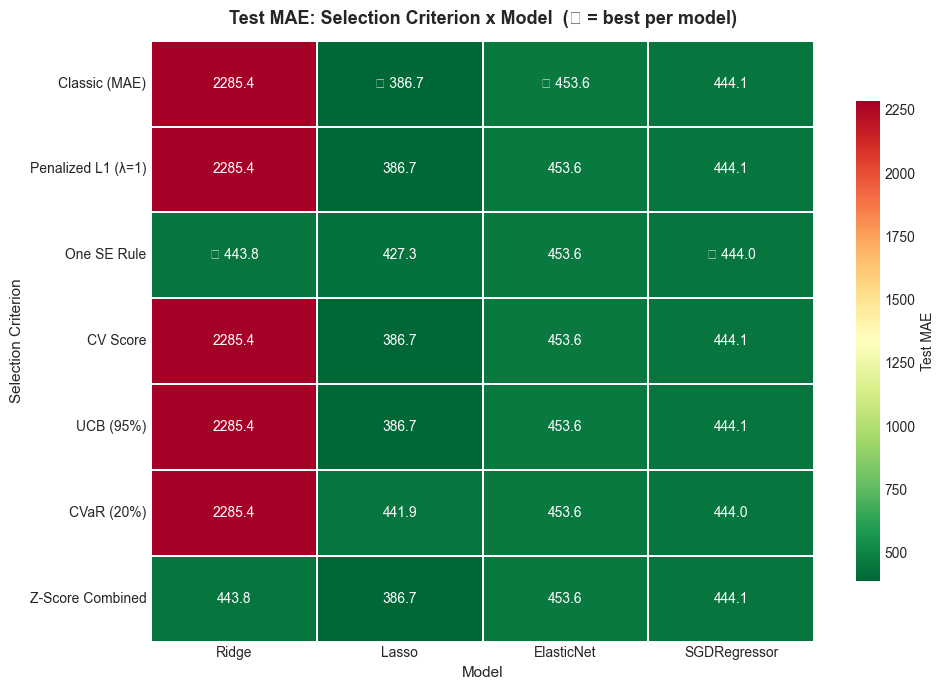

Saved: reports/figures/scoring_experiment_test_mae_heatmap.png


In [11]:
PALETTE     = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
figures_dir = Path('../reports/figures')

annot_arr = mae_pivot.copy().round(1).astype(str)
for col in MODEL_ORDER:
    best_row = mae_pivot[col].idxmin()
    annot_arr.loc[best_row, col] = '★ ' + annot_arr.loc[best_row, col]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    mae_pivot,
    annot=annot_arr, fmt='s',
    cmap='RdYlGn_r', ax=ax,
    linewidths=1.2, linecolor='white',
    cbar_kws={'label': 'Test MAE', 'shrink': 0.8},
    annot_kws={'size': 10},
)
ax.set_title(
    'Test MAE: Selection Criterion x Model  (★ = best per model)',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Selection Criterion', fontsize=11)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig(figures_dir / 'scoring_experiment_test_mae_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/figures/scoring_experiment_test_mae_heatmap.png')

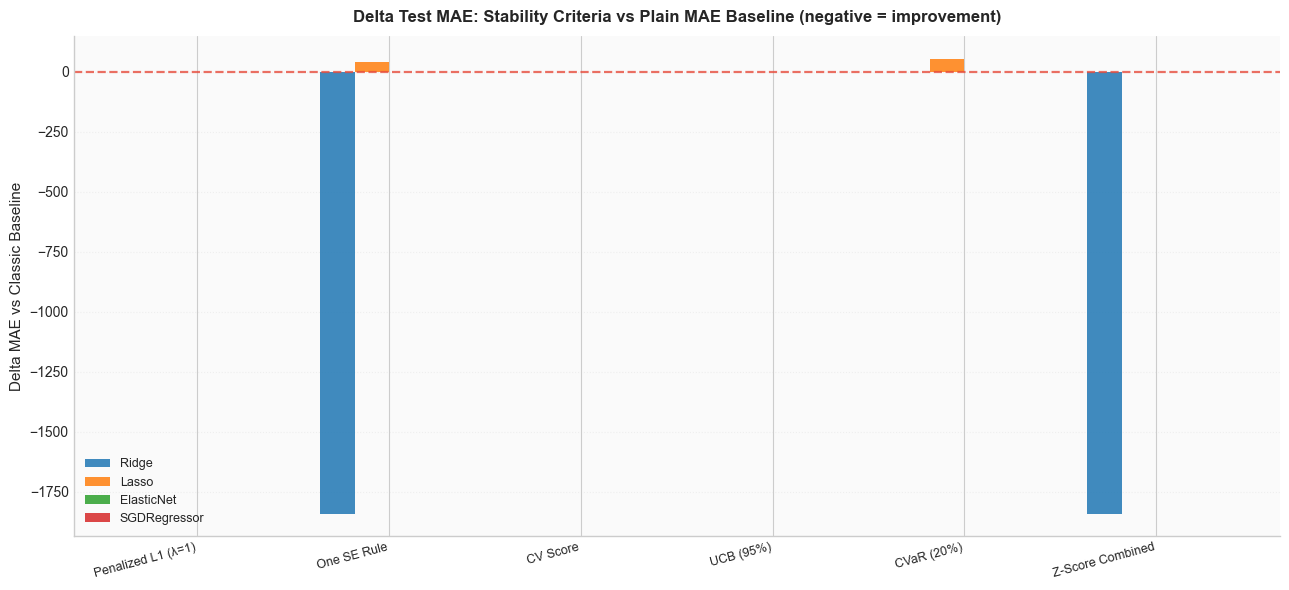

Saved: reports/figures/scoring_experiment_delta_mae.png


In [12]:
criteria_no_baseline = [c for c in CRITERION_ORDER if c != 'Classic (MAE)']
n_criteria = len(criteria_no_baseline)
width      = 0.18
x          = np.arange(n_criteria)
offsets    = np.linspace(
    -(len(MODEL_ORDER) - 1) / 2 * width,
    (len(MODEL_ORDER) - 1) / 2 * width,
    len(MODEL_ORDER),
)

fig, ax = plt.subplots(figsize=(13, 6))
for i, model_name in enumerate(MODEL_ORDER):
    vals = []
    for crit in criteria_no_baseline:
        mask = (results_df['Model'] == model_name) & (results_df['Criterion'] == crit)
        vals.append(results_df.loc[mask, 'Delta MAE'].values[0])
    ax.bar(x + offsets[i], vals, width, label=model_name,
           color=PALETTE[i], alpha=0.85, edgecolor='none')

ax.axhline(0, color='#e74c3c', linestyle='--', linewidth=1.6, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(criteria_no_baseline, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Delta MAE vs Classic Baseline', fontsize=11)
ax.set_title(
    'Delta Test MAE: Stability Criteria vs Plain MAE Baseline (negative = improvement)',
    fontsize=12, fontweight='bold', pad=10
)
ax.legend(fontsize=9, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle=':')
ax.set_facecolor('#fafafa')

plt.tight_layout()
plt.savefig(figures_dir / 'scoring_experiment_delta_mae.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/figures/scoring_experiment_delta_mae.png')